# Explorign Extraction Formatting

The goal of this notebook is to investigate:
- How well the formatting capture the bot's answer for datamodels pre_collections and RAG generations
- Performance difference in Exact Match and F1 Score when using different instructions with formating in RAG Generation

In [1]:
import polars as pl
import json
from utils.metrics.calculate_metric import calculate_agg_metric_from_dataframes
import re
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

INFO 04-05 02:19:34 [__init__.py:216] Automatically detected platform cuda.


## How well the formatting capture the bot's answer 

Given the default prompting extraction especified by the instruction, how many of the asnwers are being possible to retrieve.

In [2]:
def extract_response_null(text: str):
    pattern1 = r"response:\s*\[+(.*?)\]+"
    pattern2 = r"no-res"
    pattern3 = r"response:\s*(.*)"
    
    match1= re.search(pattern1, text.lower())
    match2 = re.search(pattern2, text.lower())
    match3 = re.search(pattern3, text.lower())
    if match1:
        return match1.group(1).strip()
    elif match2:
        return "NO-RES"
    elif match3:
        return match3.group(1).strip()
    else:
        return None
    
def extract_response(text: str):
    pattern1 = r"response:\s*\[+(.*?)\]+"
    pattern2 = r"no-res"
    pattern3 = r"response:\s*(.*)"
    
    match1= re.search(pattern1, text.lower())
    match2 = re.search(pattern2, text.lower())
    match3 = re.search(pattern3, text.lower())
    if match1:
        return match1.group(1).strip()
    elif match2:
        return "NO-RES"
    elif match3:
        return match3.group(1).strip()
    else:
        return " ".join(text.strip().split(" ")[:15])

## RAG Generations

In [3]:
RUNS_PATH = "../datamodels_runs/extraction/"
EXPERIMENTS = ["experiment_1", "experiment_4", "experiment_54", "experiment_61", "experiment_73"]
GENERATIONS = ["rag.json", "rag_reasoning.json", "rag_extraction.json"]

rag_data = {
    "generation": [],
    "experiment": [],
    "question_idx": [],
    "answer": [],
    "extracted_answer": []
}

for exp in EXPERIMENTS:
    for gen in GENERATIONS:
        data = json.load(open(f"{RUNS_PATH}/{exp}/generations/{gen}"))
        for _, item in enumerate(data):
            rag_data["generation"].append(gen.replace(".json", ""))
            rag_data["experiment"].append(exp)
            rag_data["question_idx"].append(item)
            rag_data["answer"].append(data[item][0])
            rag_data["extracted_answer"].append(extract_response_null(data[item][0]))

rag_df = pl.DataFrame(rag_data)

In [4]:
rag_df

generation,experiment,question_idx,answer,extracted_answer
str,str,str,str,str
"""rag""","""experiment_1""","""0""","""popping.""",null
"""rag""","""experiment_1""","""1""","""Tyler Hubbard and Brian Kelley…",null
"""rag""","""experiment_1""","""2""","""Robby Benson""",null
"""rag""","""experiment_1""","""3""","""1964""",null
"""rag""","""experiment_1""","""4""","""November 7, 2017""",null
…,…,…,…,…
"""rag_extraction""","""experiment_73""","""495""","""Explanation: The provided docu…","""NO-RES"""
"""rag_extraction""","""experiment_73""","""496""","""Explanation: The question is a…","""rod brind'amour is the current…"
"""rag_extraction""","""experiment_73""","""497""","""RESPONSE: [[Violet Chachki]] …","""violet chachki"""


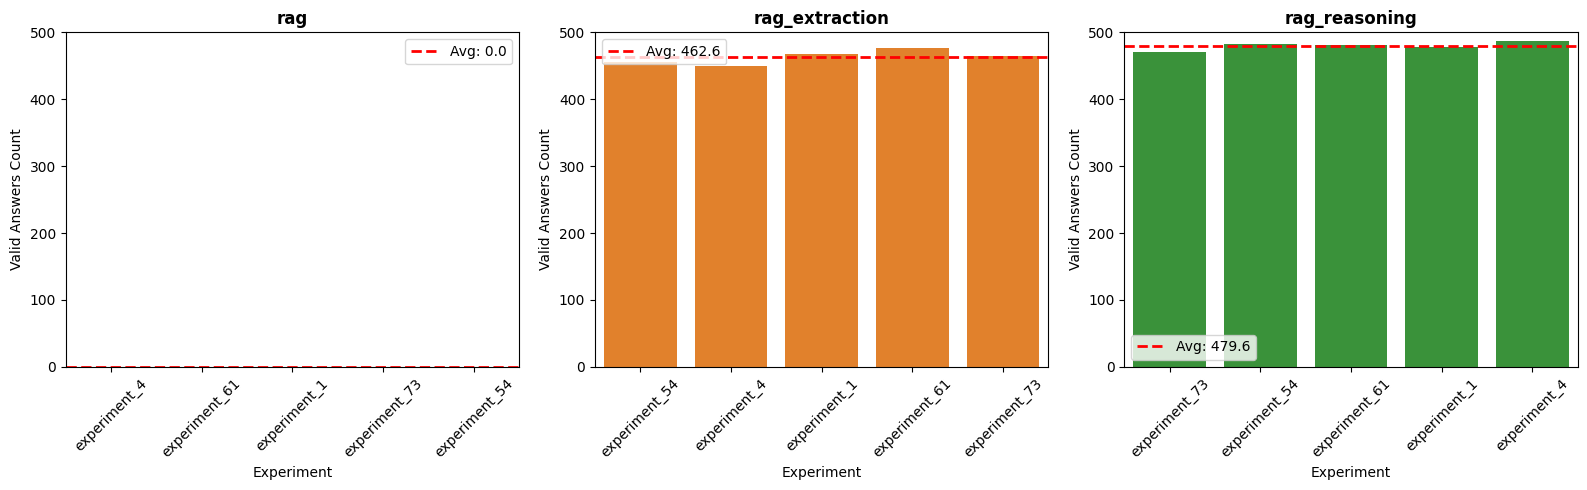

In [5]:
# Aggregate data
agg_data = (
    rag_df
    .filter(pl.col("answer").is_not_null())
    .group_by("experiment", "generation")
    .agg(pl.count("extracted_answer").alias("count"))
)

# Convert to pandas for plotting

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
generations = sorted(agg_data["generation"].unique())
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

for idx, gen in enumerate(generations):
    gen_data = agg_data.filter(pl.col("generation") == gen)
    
    sns.barplot(data=gen_data, x="experiment", y="count", 
                color=colors[idx], ax=axes[idx])
    
    # Add average line
    avg_value = gen_data["count"].mean()
    axes[idx].axhline(y=avg_value, color="red", linestyle="--", 
                      linewidth=2, label=f"Avg: {avg_value:.1f}")
    
    axes[idx].set_title(f"{gen}", fontsize=12, fontweight="bold")
    axes[idx].set_xlabel("Experiment", fontsize=10)
    axes[idx].set_ylabel("Valid Answers Count", fontsize=10)
    axes[idx].set_ylim(0, 500)
    axes[idx].legend()
    axes[idx].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [6]:
## Qualitative analysis of two missing answers in RAG Reasoning and In RAG Extraction
miss_extraction = rag_df.filter((pl.col("generation") == "rag_extraction") & (pl.col("extracted_answer").is_null())).sample(3)
miss_reasoning = rag_df.filter((pl.col("generation") == "rag_reasoning") & (pl.col("extracted_answer").is_null())).sample(3)

print("Missing Extraction:")
print(miss_extraction)
print(f"Answer 1: {miss_extraction[0, 'answer']}")
print(f"Answer 2: {miss_extraction[1, 'answer']}")
print(f"Answer 3: {miss_extraction[2, 'answer']}")
print("Missing Reasoning:")
print(miss_reasoning)
print(f"Answer 1: {miss_reasoning[0, 'answer']}")
print(f"Answer 2: {miss_reasoning[1, 'answer']}")
print(f"Answer 3: {miss_reasoning[2, 'answer']}")

Missing Extraction:
shape: (3, 5)
┌────────────────┬───────────────┬──────────────┬───────────────────────────────┬──────────────────┐
│ generation     ┆ experiment    ┆ question_idx ┆ answer                        ┆ extracted_answer │
│ ---            ┆ ---           ┆ ---          ┆ ---                           ┆ ---              │
│ str            ┆ str           ┆ str          ┆ str                           ┆ str              │
╞════════════════╪═══════════════╪══════════════╪═══════════════════════════════╪══════════════════╡
│ rag_extraction ┆ experiment_54 ┆ 323          ┆ Explanation: The question is  ┆ null             │
│                ┆               ┆              ┆ a…                            ┆                  │
│ rag_extraction ┆ experiment_54 ┆ 200          ┆ Explanation: After reviewing  ┆ null             │
│                ┆               ┆              ┆ t…                            ┆                  │
│ rag_extraction ┆ experiment_54 ┆ 290          ┆ Explana

### Pre-Collections Fomatting

In [7]:
unify_pre_collections = []

for exp in EXPERIMENTS:
    for split in ["train", "test"]:
        for f in os.listdir(f"{RUNS_PATH}/{exp}/datamodels/pre_collections/{split}"):
            if f.endswith(".feather"):
                data = pl.read_ipc(f"{RUNS_PATH}/{exp}/datamodels/pre_collections/{split}/{f}", memory_map=False)
                data = data.with_columns(pl.lit(exp).alias("experiment"), pl.lit(split).alias("split"))
                unify_pre_collections.append(data)

pre_collections_df = pl.concat(unify_pre_collections).select(["collection_idx", "test_idx", "predicted_output", "true_output", "experiment", "split"])
pre_collections_df.head()

collection_idx,test_idx,predicted_output,true_output,experiment,split
i64,i64,list[str],list[str],str,str
1250,0,"[""RESPONSE: [[last-in-first-out (LIFO)]] Explanation: The question asks about the process of removing an element from a stack, and the correct answer can be found in Document[7](Title: Stack (abstract data type)), which defines the LIFO (last-in-first-out) principle, where the order of elements is the opposite of a queue, with the most recently added element being the first to be removed.""]","[""pop""]","""experiment_1""","""train"""
1250,1,"[""Explanation: The answer to the question ""who wrote the song 'smooth' by Florida Georgia Line"" cannot be found in the provided documents. The documents only mention the song ""Cruise"" and its collaborators, but not ""Smooth"". However, it is worth noting that ""Smooth"" is not even mentioned in the documents. RESPONSE: NO-RES""]","[""Brian Kelley"", ""Jordan Schmidt"", … ""Tyler Hubbard""]","""experiment_1""","""train"""
1250,2,"[""RESPONSE: [[Dan Stevens]] Explanation: The answer can be found in Document[2](Title: Beauty and the Beast (2017 film)), where it states that Dan Stevens portrays the Beast in the 2017 live-action adaptation of ""Beauty and the Beast"".""]","[""Dan Stevens""]","""experiment_1""","""train"""
1250,3,"[""Explanation: The question asks for the year when Spain won their first World Cup, and the documents provided cover various periods in the history of the Spanish national football team. Response: [[2010]]""]","[""2010""]","""experiment_1""","""train"""
1250,4,"[""Explanation: The provided documents do not mention ""Diary of a Wimpy Kid: The Getaway"". RESPONSE: NO-RES""]","[""November 7 , 2017""]","""experiment_1""","""train"""


In [8]:
extracted_answers = [extract_response_null(res[0]) for res in pre_collections_df["predicted_output"].to_list()]
pre_collections_df = pre_collections_df.with_columns(pl.Series(extracted_answers).alias("extracted_answer"))
pre_collections_df.head()

collection_idx,test_idx,predicted_output,true_output,experiment,split,extracted_answer
i64,i64,list[str],list[str],str,str,str
1250,0,"[""RESPONSE: [[last-in-first-out (LIFO)]] Explanation: The question asks about the process of removing an element from a stack, and the correct answer can be found in Document[7](Title: Stack (abstract data type)), which defines the LIFO (last-in-first-out) principle, where the order of elements is the opposite of a queue, with the most recently added element being the first to be removed.""]","[""pop""]","""experiment_1""","""train""","""last-in-first-out (lifo)"""
1250,1,"[""Explanation: The answer to the question ""who wrote the song 'smooth' by Florida Georgia Line"" cannot be found in the provided documents. The documents only mention the song ""Cruise"" and its collaborators, but not ""Smooth"". However, it is worth noting that ""Smooth"" is not even mentioned in the documents. RESPONSE: NO-RES""]","[""Brian Kelley"", ""Jordan Schmidt"", … ""Tyler Hubbard""]","""experiment_1""","""train""","""NO-RES"""
1250,2,"[""RESPONSE: [[Dan Stevens]] Explanation: The answer can be found in Document[2](Title: Beauty and the Beast (2017 film)), where it states that Dan Stevens portrays the Beast in the 2017 live-action adaptation of ""Beauty and the Beast"".""]","[""Dan Stevens""]","""experiment_1""","""train""","""dan stevens"""
1250,3,"[""Explanation: The question asks for the year when Spain won their first World Cup, and the documents provided cover various periods in the history of the Spanish national football team. Response: [[2010]]""]","[""2010""]","""experiment_1""","""train""","""2010"""
1250,4,"[""Explanation: The provided documents do not mention ""Diary of a Wimpy Kid: The Getaway"". RESPONSE: NO-RES""]","[""November 7 , 2017""]","""experiment_1""","""train""","""NO-RES"""


In [9]:
pre_collections_df.filter(pl.col("extracted_answer").is_null()).group_by("experiment").agg(pl.count())

/tmp/ipykernel_574191/543256489.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pre_collections_df.filter(pl.col("extracted_answer").is_null()).group_by("experiment").agg(pl.count())


experiment,count
str,u32
"""experiment_1""",118680
"""experiment_4""",123958
"""experiment_54""",120264
"""experiment_61""",113882
"""experiment_73""",117954


## Results - RAG Generations

In [27]:
LOAD = False
generations = ["rag", "rag_reasoning", "rag_extraction"]


rag_data = {
    "generation": [],
    "experiment": [],
    "question_idx": [],
    "answer": [],
    "extracted_answer": []
}

for exp in EXPERIMENTS:
    for gen in GENERATIONS:
        data = json.load(open(f"{RUNS_PATH}/{exp}/generations/{gen}"))
        for _, item in enumerate(data):
            rag_data["generation"].append(gen.replace(".json", ""))
            rag_data["experiment"].append(exp)
            rag_data["question_idx"].append(item)
            rag_data["answer"].append(data[item][0])
            rag_data["extracted_answer"].append(extract_response(data[item][0]))

_rag_df = pl.DataFrame(rag_data)

if not LOAD:
    dfs_generations = []
    
    # Load questions dataframe from first experiment

    
    for gen_method in generations:
        for exp in EXPERIMENTS:
            questions_path = f"../datamodels_runs/extraction/{exp}/questions.feather"
        # Filter _rag_df for this generation method
            gen_filtered = _rag_df.filter(pl.col("generation") == gen_method).filter(pl.col("experiment") == exp)
            
            print(f"Processing {gen_method}...")
            result = calculate_agg_metric_from_dataframes(
                metrics=["rouge_l", "squad_v2_best_exact"],
                generations_df=gen_filtered,
                reference_path=questions_path,
                generation_column="extracted_answer",          
            )


            
            # Add generation_method column
            result = result.with_columns(pl.lit(gen_method).alias("generation_method"), pl.lit(exp).alias("experiment"))
            dfs_generations.append(result)

    generations_results = pl.concat(dfs_generations)
    generations_results.write_ipc("extraction_results.feather")


Processing rag...
Calculating rouge_l...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


Calculating squad_v2_best_exact...


Processing rag...
Calculating rouge_l...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


...

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


Calculating squad_v2_best_exact...


Processing rag_extraction...
Calculating rouge_l...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


Calculating squad_v2_best_exact...


In [26]:
generations_results

idx,value,metric,generation_method
i64,f32,str,str
0,0.0,"""rouge_l""","""rag"""
1,0.307692,"""rouge_l""","""rag"""
2,0.0,"""rouge_l""","""rag"""
3,0.0,"""rouge_l""","""rag"""
4,1.0,"""rouge_l""","""rag"""
…,…,…,…
495,0.0,"""squad_v2_best_exact""","""rag_extraction"""
496,0.0,"""squad_v2_best_exact""","""rag_extraction"""
497,0.0,"""squad_v2_best_exact""","""rag_extraction"""


In [28]:
generations_results.group_by("generation_method", "metric").agg(pl.mean("value")).sort("metric", "generation_method")

generation_method,metric,value
str,str,f32
"""rag""","""rouge_l""",0.449655
"""rag_extraction""","""rouge_l""",0.391366
"""rag_reasoning""","""rouge_l""",0.377608
"""rag""","""squad_v2_best_exact""",0.3176
"""rag_extraction""","""squad_v2_best_exact""",0.2884
"""rag_reasoning""","""squad_v2_best_exact""",0.2684


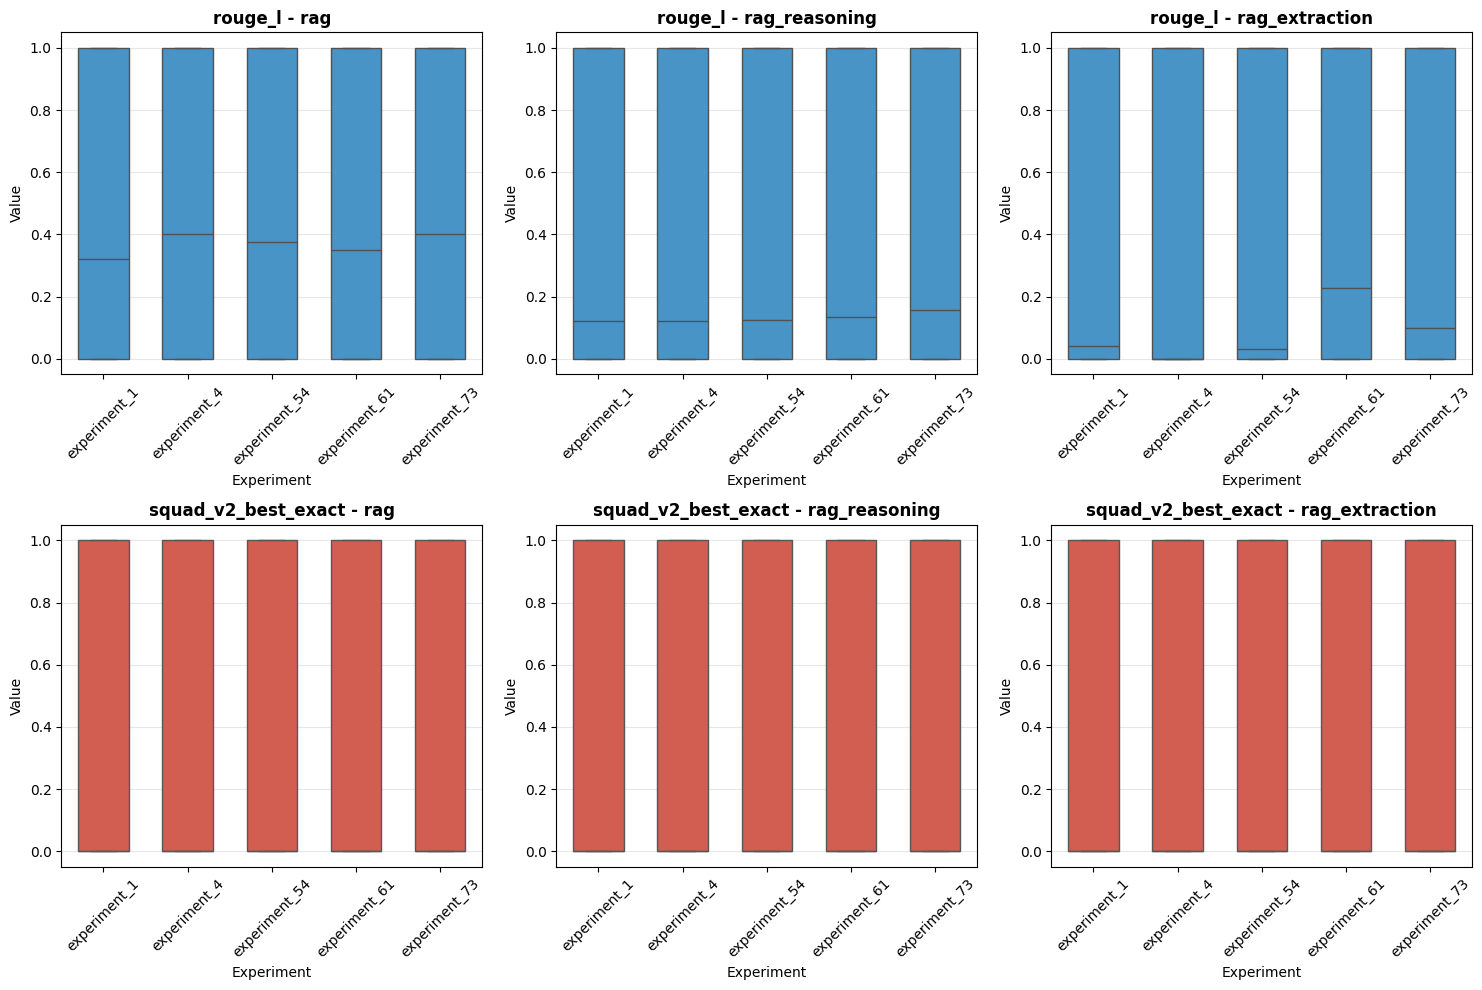

In [29]:
generations_results = pl.read_ipc("extraction_results.feather")

# Define metrics, generation methods, and colors
metrics = ["rouge_l", "squad_v2_best_exact"]
generation_methods = ["rag", "rag_reasoning", "rag_extraction"]
row_colors = ["#3498db", "#e74c3c"]  # Blue for first row, Red for second row

# Create 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Iterate through metrics (rows) and generation methods (columns)
for row_idx, metric in enumerate(metrics):
    for col_idx, gen_method in enumerate(generation_methods):
        ax = axes[row_idx, col_idx]
        
        # Filter data for current metric and generation method
        data = generations_results.filter(
            (pl.col("metric") == metric) & 
            (pl.col("generation_method") == gen_method)
        ).to_pandas()
        
        # Create boxplot
        sns.boxplot(
            data=data,
            x="experiment",
            y="value",
            ax=ax,
            color=row_colors[row_idx],
            width=0.6
        )
        
        # Set title and labels
        ax.set_title(f"{metric} - {gen_method}", fontsize=12, fontweight="bold")
        ax.set_xlabel("Experiment", fontsize=10)
        ax.set_ylabel("Value", fontsize=10)
        ax.tick_params(axis="x", rotation=45)
        ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()